In [72]:
import matplotlib.pyplot as plt
from src.TimeSeriesAnalysis import select_random_json, read_experiment_json, load_properties_bundle, create_folder
from IPython.display import clear_output
from src.TimeSeriesAnalysis import detect_equilibrium_start_with_errors, weighted_mean_and_sem, idx_from_t0, read_mean_json
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, LinearLocator,FormatStrFormatter
from matplotlib.lines import Line2D
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from tqdm import tqdm
import pandas as pd
import os
import numpy as np

In [73]:
results_folder = "../results/conditions_effects/3D"
create_folder(results_folder)

## p(t) SERIES - $p_0$ effects for differents sizes

File not found: ../SOP_data/published/bond_percolation/num_colors_2/dim_3/L_1024/fT_constant/fT_1.000000e-01/c_1.500000e-01/rho_5.0000e-01/properties_mean_bundle.json
File not found: ../SOP_data/published/bond_percolation/num_colors_4/dim_3/L_1024/fT_constant/fT_1.000000e-01/c_1.500000e-01/rho_2.5000e-01/properties_mean_bundle.json
File not found: ../SOP_data/published/bond_percolation/num_colors_8/dim_3/L_1024/fT_constant/fT_1.000000e-01/c_1.500000e-01/rho_1.2500e-01/properties_mean_bundle.json


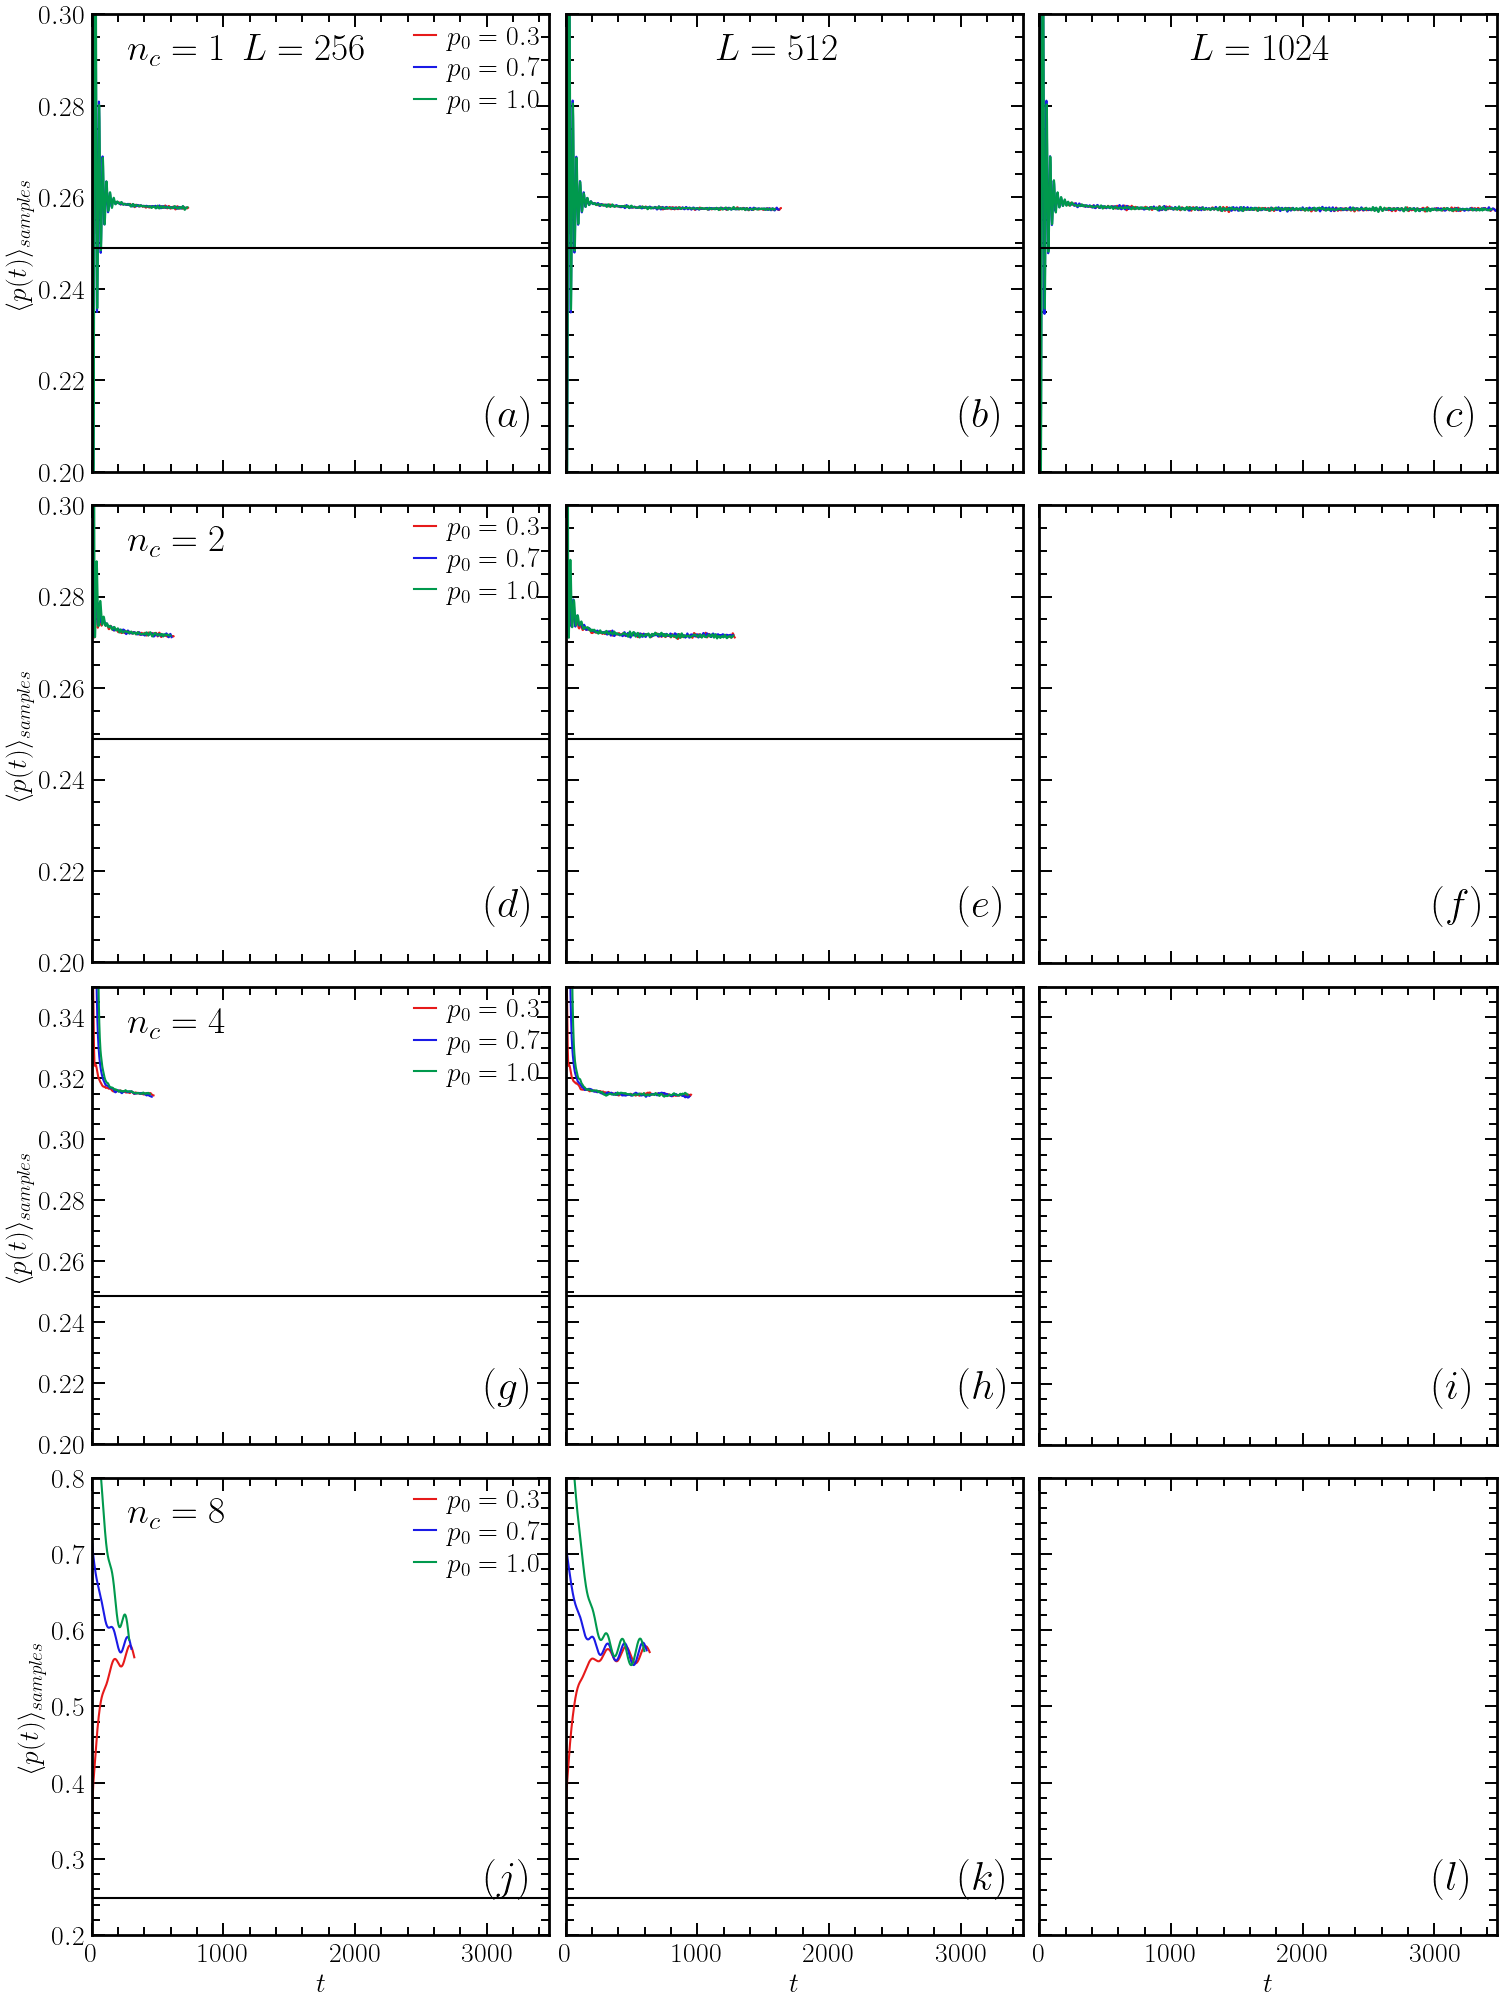

In [74]:
#fT = 0.05
#c = 0.01
fT = 0.1
c=0.15
L_lst = [256, 512, 1024]
dim = 3
nc_lst = [1, 2, 4, 8]

base = 5
p0_values = [0.3, 0.7, 1.0]
fig, axes = plt.subplots(len(nc_lst), len(L_lst), figsize=(3*base, 4*base), constrained_layout=True, sharex=True, sharey='row')
order_mean = 0
pc = 0.24881182
colors = [
    (0.90, 0.10, 0.10),  # red
    (0.10, 0.10, 0.90),  # blue
    (0.00, 0.60, 0.30),  # green
    (0.95, 0.50, 0.00),  # orange
    (0.65, 0.20, 0.75),  # purple
    (0.00, 0.70, 0.70),  # teal
    (0.55, 0.55, 0.00),  # olive
    (0.45, 0.25, 0.10),  # brown
]
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$',
              r'$(d)$', r'$(e)$', r'$(f)$',
              r'$(g)$', r'$(h)$', r'$(i)$',
              r'$(j)$', r'$(k)$', r'$(l)$',]

fs_labels_fig = 30
fs_l_fig = 27

t_max = 0
parms_need = []
for idx_nc, nc in enumerate(nc_lst):
    for idx_L, L in enumerate(L_lst):
        ax = axes[idx_nc, idx_L]
        rho = 1/nc
        path = f"../SOP_data/published/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/fT_constant/fT_{fT:.6e}/c_{c:.6e}/rho_{rho:.4e}"
        fn = path + "/properties_mean_bundle.json"
        try:
            bundle = load_properties_bundle(fn)
            for idx_p0, p0 in enumerate(p0_values):
                try:
                    data = bundle[p0]["orders"][order_mean]
                
                except KeyError:
                    print(f"KeyError for p0 = {p0}")
                    parms_need.append((nc, L, p0))
                    continue
                time = data["time"]
                pt_mean = data["pt_mean"]
                ax.plot(time, pt_mean, ls='solid', color=colors[idx_p0], label=f'$p_0 = {p0}$')
                t_max = max(t_max, max(time))
        
        except FileNotFoundError:
            print(f"File not found: {fn}")
            parms_need.append((nc, L, p0))
            continue
        ax.axhline(pc, color='k', ls='solid')
        ax.set_ylim(0.2, 0.8)
        ax.set_box_aspect(1)        
        
        if idx_L == 0:
            ax.text(0.08, 0.9, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
            ax.legend()
        if idx_nc == 0:
            ax.text(0.33, 0.9, f'$L = {L}$', transform=ax.transAxes , fontsize=fs_l_fig)
        
        if idx_nc ==0 or idx_nc == 1:
            ax.set_ylim(0.2, 0.3)
        elif idx_nc == 2:
            ax.set_ylim(0.2, 0.35)
        elif idx_nc == 3:
            ax.set_ylim(0.2, 0.8)
        
for idx, ax in enumerate(axes.flatten()):
    ax.set_xlim(0, t_max)
    ax.text(0.86, 0.10, labels_fig[idx], transform=ax.transAxes , fontsize=fs_labels_fig)

for ax in axes[:,0]:
    ax.set_ylabel(r'$\langle p(t) \rangle_{samples}$')
for ax in axes[-1,:]:
    ax.set_xlabel(r'$t$')

#fig.suptitle(f"dim $= {dim}$, $f_T = {fT}$, $n_s = 1$, $c = {c}$", fontsize=30)
#plt.savefig(results_folder + f"/pt_multiply_L.svg")
plt.show()


## Height Effects ($z=L$, $z=2L$, $z=3L$)

Loading data for nc=1, ft=0.1
Loading data for nc=1, ft=0.2
Loading data for nc=1, ft=0.3
Loading data for nc=1, ft=0.4
Loading data for nc=1, ft=0.1
Loading data for nc=1, ft=0.2
Loading data for nc=1, ft=0.3
Loading data for nc=1, ft=0.4
Loading data for nc=1, ft=0.1
Loading data for nc=1, ft=0.2
Loading data for nc=1, ft=0.3
Loading data for nc=1, ft=0.4
Loading data for nc=2, ft=0.1
Loading data for nc=2, ft=0.2
Loading data for nc=2, ft=0.3
Loading data for nc=2, ft=0.4
Loading data for nc=2, ft=0.1
Loading data for nc=2, ft=0.2
Loading data for nc=2, ft=0.3
Loading data for nc=2, ft=0.4
Loading data for nc=2, ft=0.1
Loading data for nc=2, ft=0.2
Loading data for nc=2, ft=0.3
Loading data for nc=2, ft=0.4
Loading data for nc=4, ft=0.1
Loading data for nc=4, ft=0.2
Loading data for nc=4, ft=0.3
Loading data for nc=4, ft=0.4
Loading data for nc=4, ft=0.1
Loading data for nc=4, ft=0.2
Loading data for nc=4, ft=0.3
Loading data for nc=4, ft=0.4
Loading data for nc=4, ft=0.1
Loading da

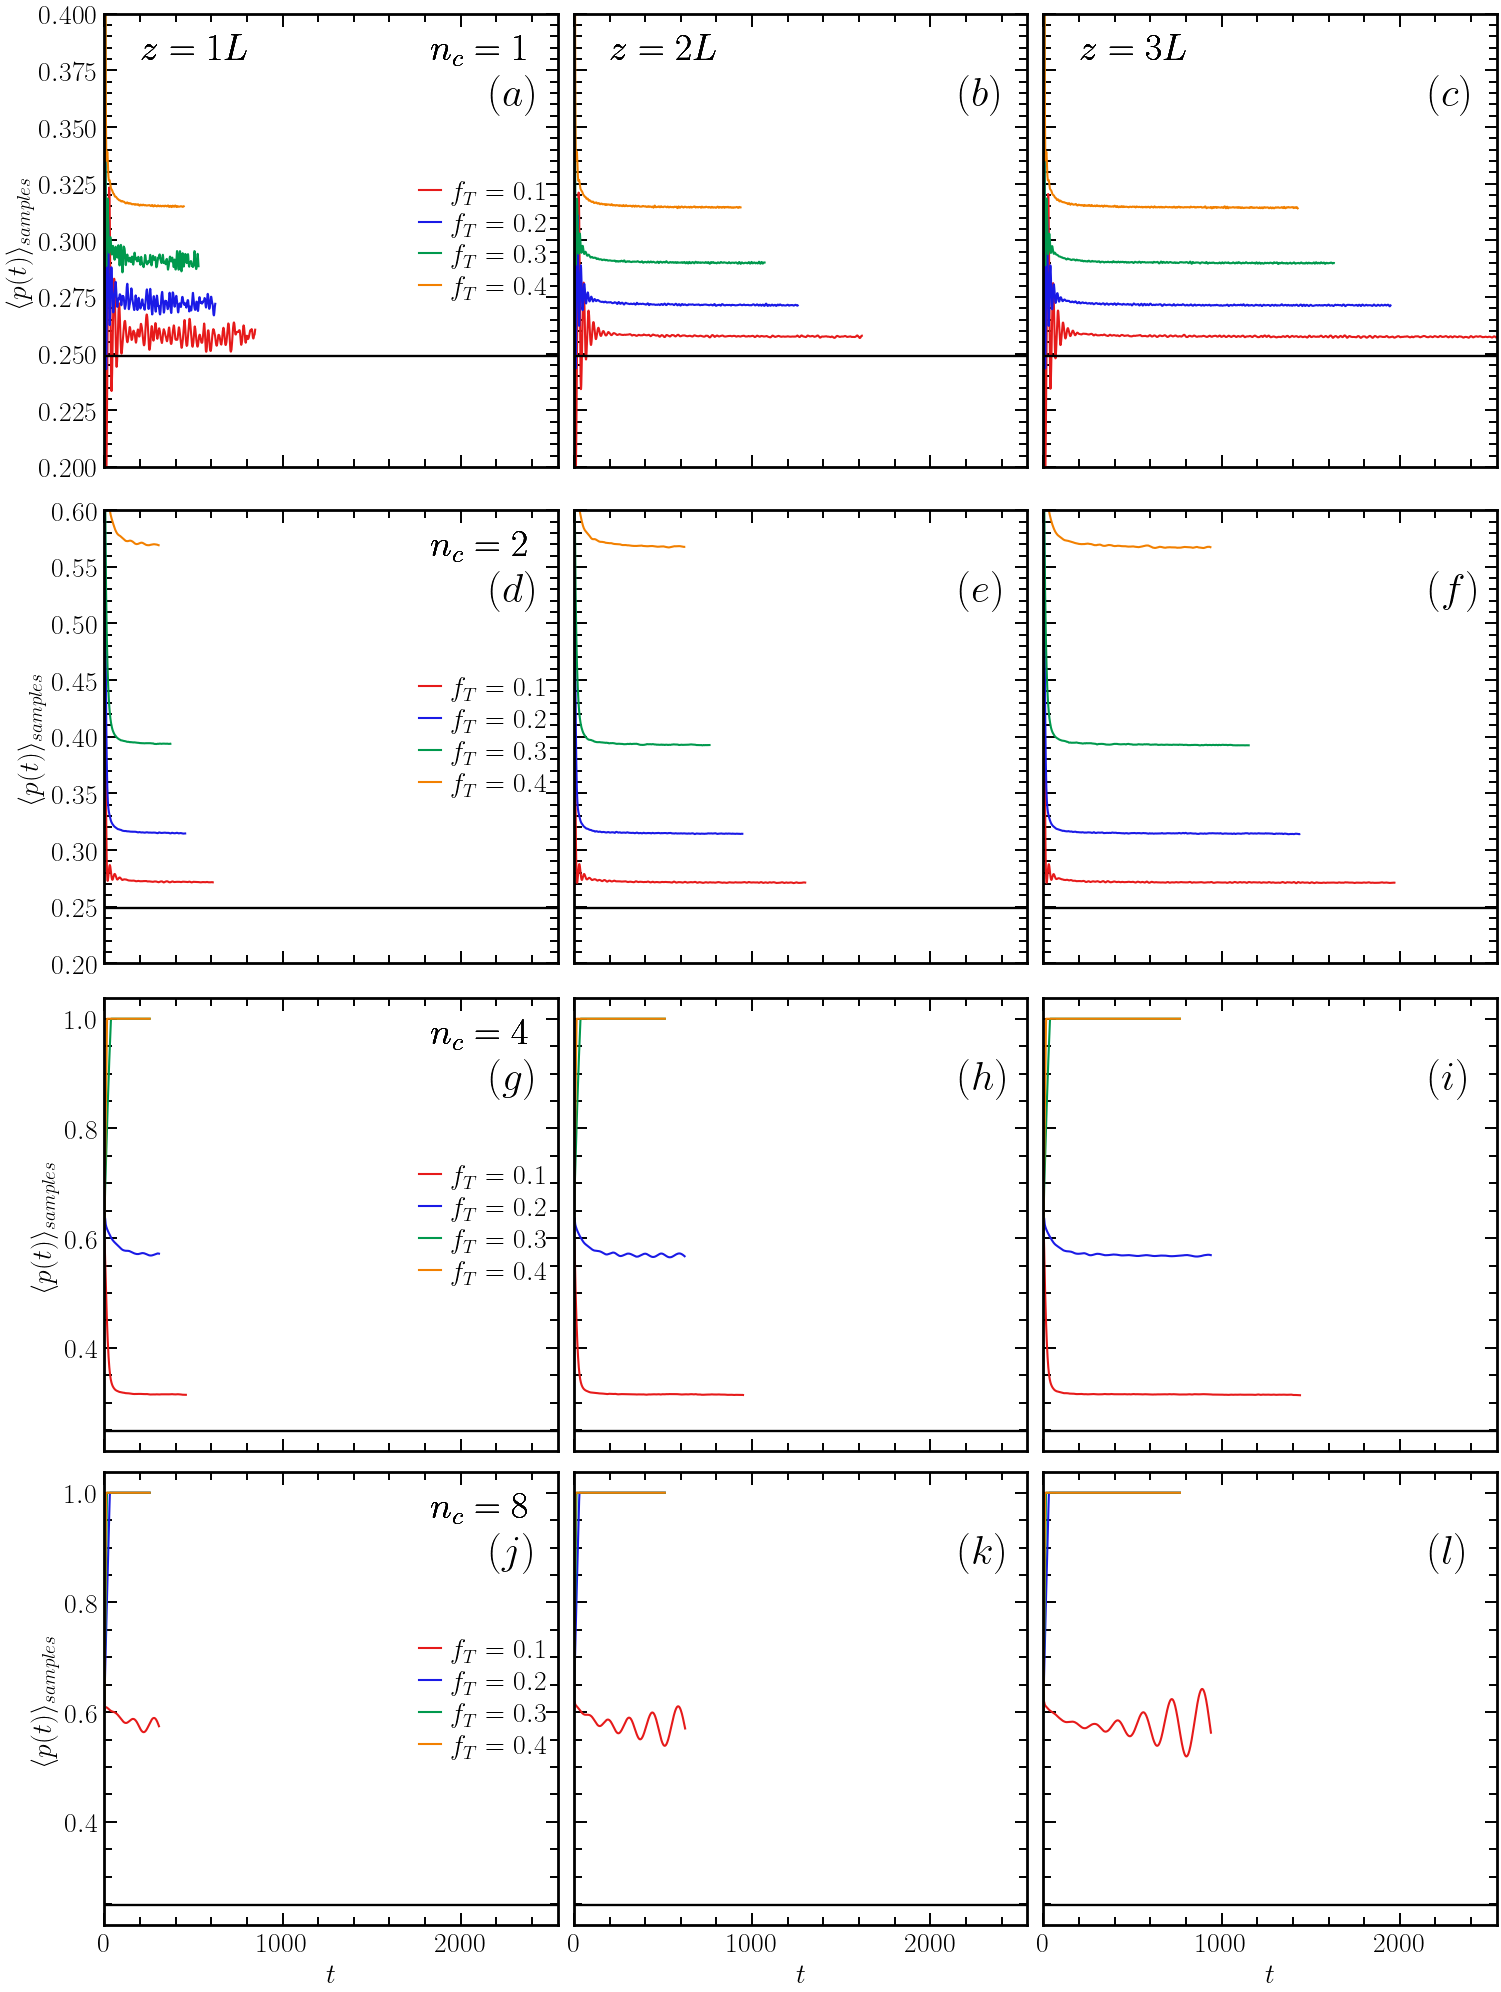

In [75]:
fT_lst = [0.1, 0.2, 0.3, 0.4]
c = 0.15
L = 256
dim = 3
nc_lst = [1, 2, 4, 8]
p0 = 0.6
base = 5
#p0_values = [0.3, 0.7, 1.0]
fig, axes = plt.subplots(len(nc_lst), 3, figsize=(3*base, 4*base), constrained_layout=True, sharex=True)
order_mean = 0
pc = 0.24881182
colors = [
    (0.90, 0.10, 0.10),  # red
    (0.10, 0.10, 0.90),  # blue
    (0.00, 0.60, 0.30),  # green
    (0.95, 0.50, 0.00),  # orange
    (0.65, 0.20, 0.75),  # purple
    (0.00, 0.70, 0.70),  # teal
    (0.55, 0.55, 0.00),  # olive
    (0.45, 0.25, 0.10),  # brown
]
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$',
              r'$(d)$', r'$(e)$', r'$(f)$',
              r'$(g)$', r'$(h)$', r'$(i)$',
              r'$(j)$', r'$(k)$', r'$(l)$',]

fs_labels_fig = 30
fs_l_fig = 27

t_max = 0
parms_list = []
for idx_nc, nc in enumerate(nc_lst):
    for index in range(3):
        ax = axes[idx_nc, index]
        for idx_ft, ft in enumerate(fT_lst):
        
            rho = 1/nc
            if(index == 0):
                path = f"../SOP_data/published/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/fT_constant/fT_{ft:.6e}/c_{c:.6e}/rho_{rho:.4e}"
            elif(index == 1):
                path = f"../SOP_data/published_2L_stop/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/fT_constant/fT_{ft:.6e}/c_{c:.6e}/rho_{rho:.4e}"
            elif(index == 2):
                path = f"../SOP_data/published_3L_stop/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/fT_constant/fT_{ft:.6e}/c_{c:.6e}/rho_{rho:.4e}"
            
            fn = path + "/properties_mean_bundle.json"
            try:
                bundle = load_properties_bundle(fn)
                data = bundle[p0]["orders"][order_mean]
                time = data["time"]
                pt_mean = data["pt_mean"]
                t_max = max(t_max, max(time))
                ax.plot(time, pt_mean, ls='solid', color=colors[idx_ft], label=f'$f_T = {ft}$')
            except KeyError:
                print(f"File not found: {fn}")
                parms_list.append((nc, ft, p0, path))
                continue
            except FileNotFoundError:
                print(f"File not found: {fn}")
                parms_list.append((nc, ft, p0, path))
                continue
            print(f'Loading data for nc={nc}, ft={ft}')
            
            
            ax.axhline(pc, color='k', ls='solid')
            #ax.set_ylim(0.245, 0.265)
            ax.set_box_aspect(1)
            if idx_nc == 0:
                ax.text(0.08, 0.9, f'$z = {index+1}L$', transform=ax.transAxes , fontsize=fs_l_fig)
                ax.set_ylim(0.2, 0.4)
            if idx_nc == 1:
                ax.set_ylim(0.2, 0.6)
            if idx_nc == 2 and idx_nc==3:
                ax.set_ylim(0.2, 1.0)
            if index==0:
                ax.legend()
                ax.set_ylabel(r'$\langle p(t) \rangle_{samples}$')
                ax.text(0.72, 0.9, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
            if idx_nc == len(nc_lst)-1:
                ax.set_xlabel(r'$t$')
            if index != 0:
                ax.tick_params(axis='y', labelleft=False)

for idx, ax in enumerate(axes.flatten()):
    ax.set_xlim(0, t_max)
    ax.text(0.85, 0.80, labels_fig[idx], transform=ax.transAxes , fontsize=fs_labels_fig)
plt.show()

## Order Percolation Effects

Loading data for nc=1, ft=0.1
File not found: ../SOP_data/published/bond_percolation/num_colors_1/dim_3/L_512/fT_constant/fT_1.000000e-01/c_1.500000e-01/rho_1.0000e+00/properties_mean_bundle.json
File not found: ../SOP_data/published/bond_percolation/num_colors_1/dim_3/L_1024/fT_constant/fT_1.000000e-01/c_1.500000e-01/rho_1.0000e+00/properties_mean_bundle.json
Loading data for nc=2, ft=0.1
Loading data for nc=2, ft=0.1
File not found: ../SOP_data/published/bond_percolation/num_colors_2/dim_3/L_1024/fT_constant/fT_1.000000e-01/c_1.500000e-01/rho_5.0000e-01/properties_mean_bundle.json
Loading data for nc=4, ft=0.1
Loading data for nc=4, ft=0.1
File not found: ../SOP_data/published/bond_percolation/num_colors_4/dim_3/L_1024/fT_constant/fT_1.000000e-01/c_1.500000e-01/rho_2.5000e-01/properties_mean_bundle.json
Loading data for nc=8, ft=0.1
Loading data for nc=8, ft=0.1
File not found: ../SOP_data/published/bond_percolation/num_colors_8/dim_3/L_1024/fT_constant/fT_1.000000e-01/c_1.500000e-01

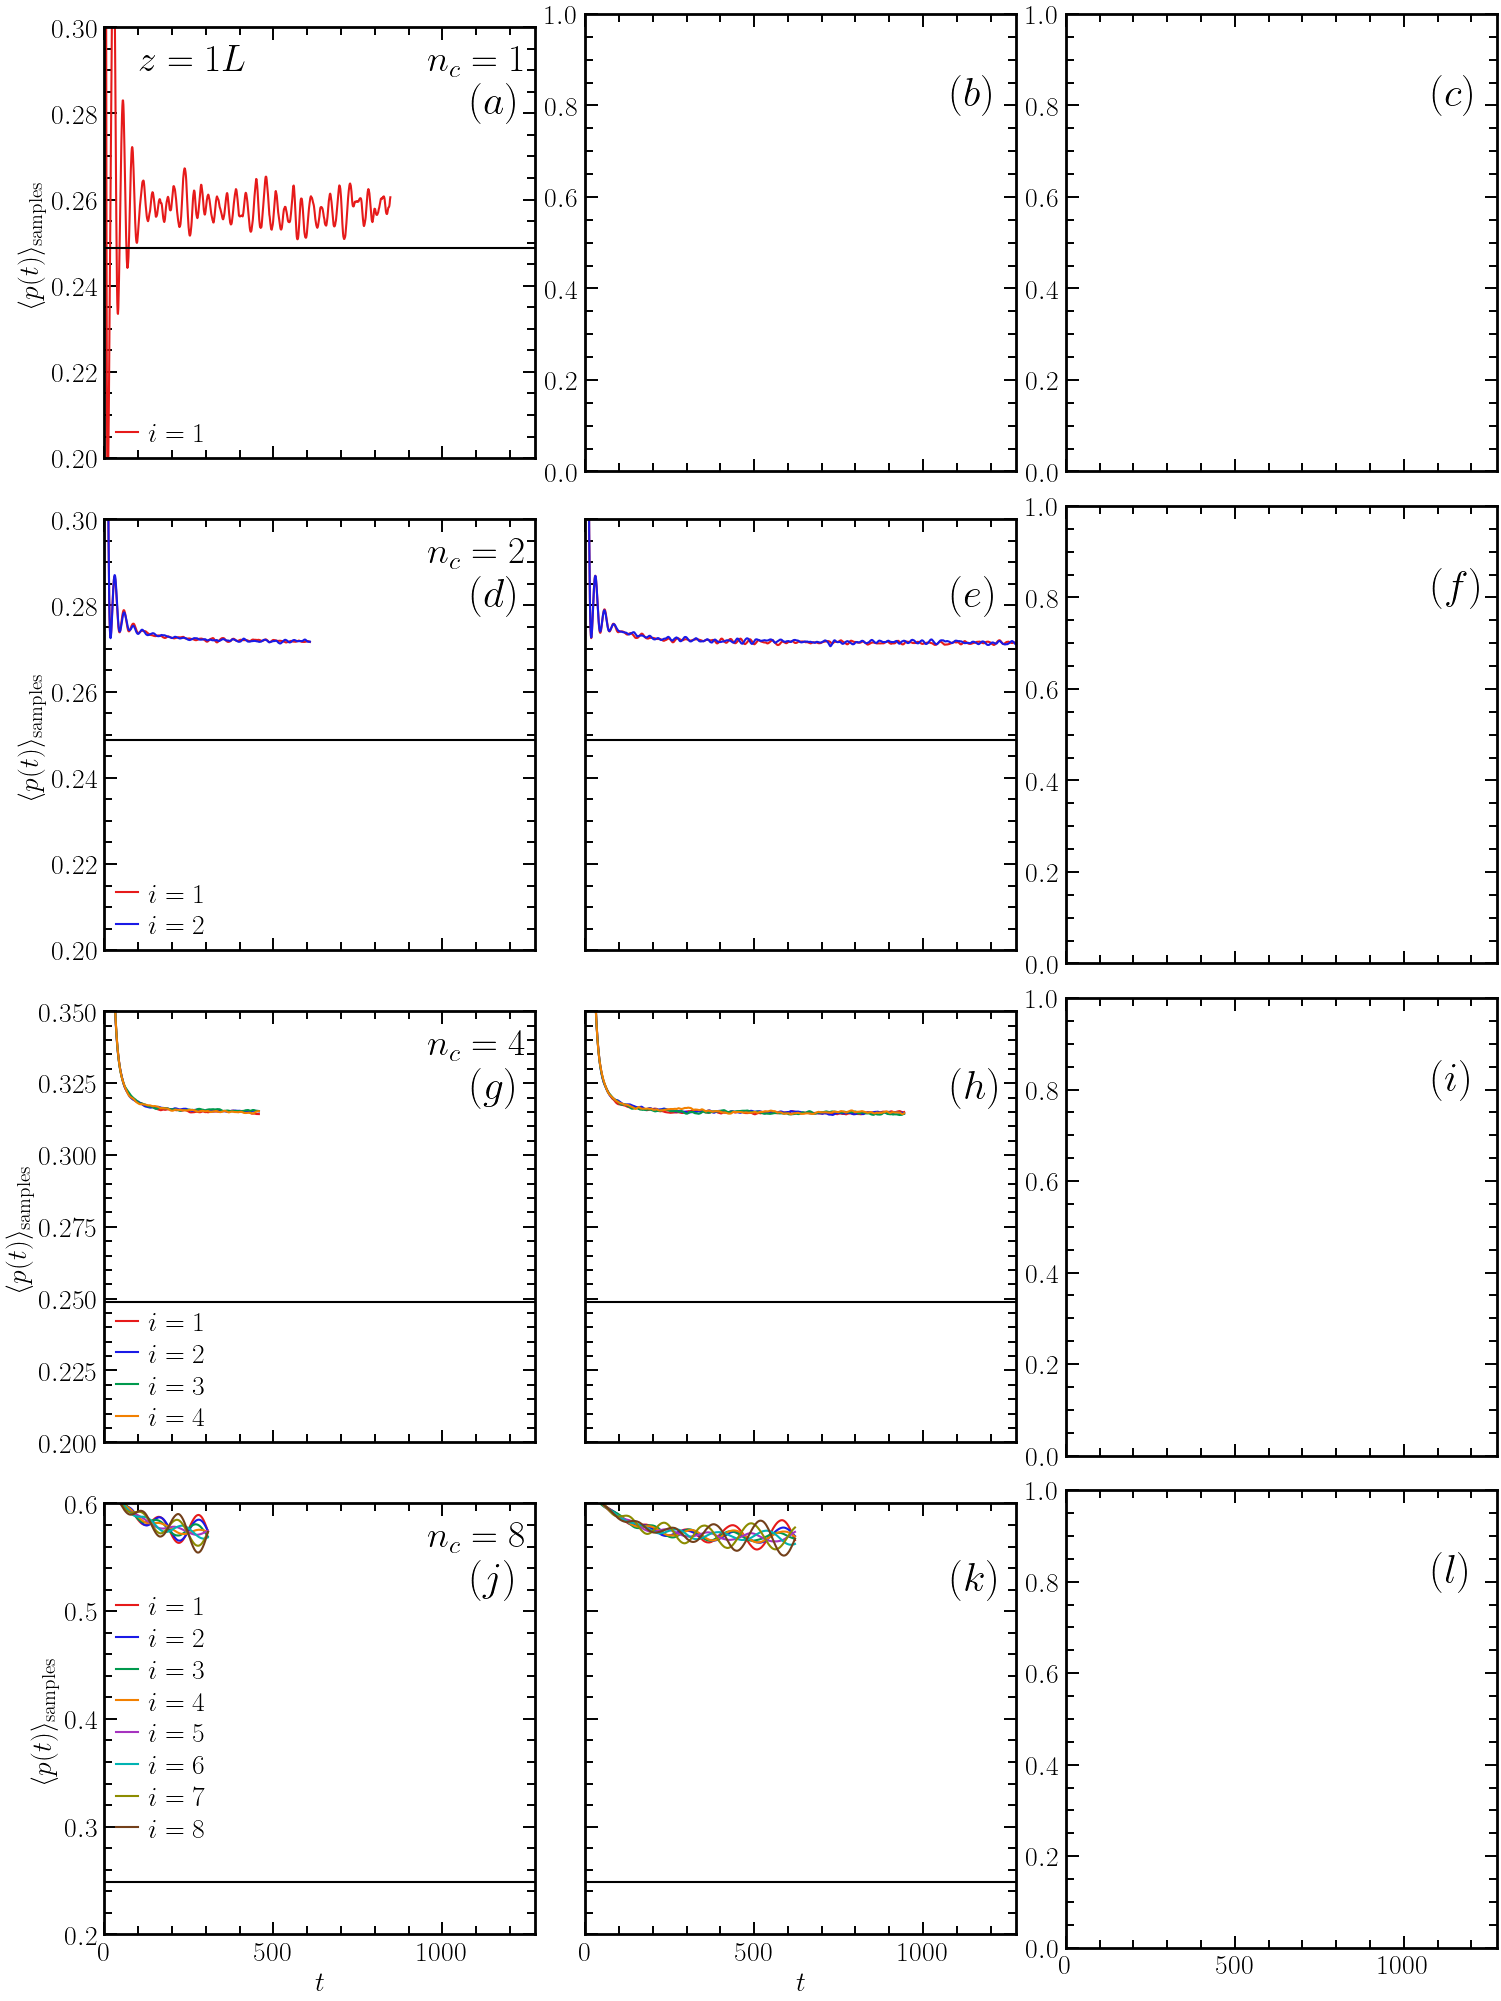

In [76]:
ft = 0.1
c = 0.15
L = [256, 512, 1024]
dim = 3
nc_lst = [1, 2, 4, 8]
p0 = 0.6
P0 = 0.1
base = 5
#p0_values = [0.3, 0.7, 1.0]
fig, axes = plt.subplots(len(nc_lst), 3, figsize=(3*base, 4*base), constrained_layout=True, sharex=True)
pc = 0.24881182
colors = [
    (0.90, 0.10, 0.10),  # red
    (0.10, 0.10, 0.90),  # blue
    (0.00, 0.60, 0.30),  # green
    (0.95, 0.50, 0.00),  # orange
    (0.65, 0.20, 0.75),  # purple
    (0.00, 0.70, 0.70),  # teal
    (0.55, 0.55, 0.00),  # olive
    (0.45, 0.25, 0.10),  # brown
]
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$',
              r'$(d)$', r'$(e)$', r'$(f)$',
              r'$(g)$', r'$(h)$', r'$(i)$',
              r'$(j)$', r'$(k)$', r'$(l)$',]

fs_labels_fig = 30
fs_l_fig = 27

t_max = 0
parms_list = []
for idx_nc, nc in enumerate(nc_lst):
    for index, L in enumerate(L_lst):
        ax = axes[idx_nc, index]
    
        rho = 1/nc            
        path = f"../SOP_data/published/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/fT_constant/fT_{ft:.6e}/c_{c:.6e}/rho_{rho:.4e}"
        
        fn = path + "/properties_mean_bundle.json"
        try:
            bundle = load_properties_bundle(fn)
            data = bundle[p0]["orders"]
            orders = data.keys()
            for idx, ord in enumerate(orders):
                data_keys = data[ord]
                time = data_keys["time"]
                pt_mean = data_keys["pt_mean"]
                t_max = max(t_max, max(time))
                ax.plot(time, pt_mean, ls='solid', color=colors[idx], label=f'$i = {ord + 1}$')
        
        except KeyError:
            print(f"File not found: {fn}")
            parms_list.append((nc, ft, p0, path))
            continue
        except FileNotFoundError:
            print(f"File not found: {fn}")
            parms_list.append((nc, ft, p0, path))
            continue
        
        print(f'Loading data for nc={nc}, ft={ft}')
        
        t_max = max(t_max, max(time))
        ax.set_ylim(0.2, 0.6)
        ax.axhline(pc, color='k', ls='solid')
        #ax.set_ylim(0.245, 0.265)
        ax.set_box_aspect(1)
        
        if(idx_nc == 0):
            ax.text(0.08, 0.9, f'$z = {index+1}L$', transform=ax.transAxes , fontsize=fs_l_fig)
            ax.set_ylim(0.2, 0.30)
            ax.set_ylim(0.2, 0.3)
        if idx_nc==1:
            ax.set_ylim(0.2, 0.3)
        if idx_nc==2:
            ax.set_ylim(0.2, 0.35)
        if idx_nc == 3:
            ax.set_ylim(0.2, 0.6)
        
        if index==2:
            ax.legend()

        if index==0:
            ax.text(0.75, 0.9, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
            ax.legend()
            ax.set_ylabel(r'$\langle p(t) \rangle_{\mathrm{samples}}$')
        if idx_nc == len(nc_lst)-1:
            ax.set_xlabel(r'$t$')
        if index != 0:
            ax.tick_params(axis='y', labelleft=False)

for idx, ax in enumerate(axes.flatten()):
    ax.set_xlim(0, t_max)
    ax.text(0.85, 0.80, labels_fig[idx], transform=ax.transAxes , fontsize=fs_labels_fig)

plt.show()

## Initial Activate Effects

In [77]:
import json

def load_properties_bundle(fn):
    with open(fn, "r") as f:
        return json.load(f)

def get_group_by_p0_P0(bundle, p0_target, P0_target, tol=1e-12):
    """
    Seleciona o bloco correto dentro de properties_mean_bundle.json
    usando simultaneamente p0_value e P0_value.
    """
    for group in bundle["p0_groups"]:
        p0_value = float(group["p0_value"])
        P0_value = float(group["P0_value"])

        if abs(p0_value - p0_target) < tol and abs(P0_value - P0_target) < tol:
            return group

    raise ValueError(f"Não encontrei grupo com p0={p0_target} e P0={P0_target}")

Error occurred while processing ../SOP_data/published/bond_percolation/num_colors_1/dim_3/L_256/fT_constant/fT_1.000000e-01/c_1.500000e-01/rho_1.0000e+00/properties_mean_bundle.json: list index out of range
Error occurred while processing ../SOP_data/published/bond_percolation/num_colors_1/dim_3/L_512/fT_constant/fT_1.000000e-01/c_1.500000e-01/rho_1.0000e+00/properties_mean_bundle.json: Não encontrei grupo com p0=0.6 e P0=0.1
Error occurred while processing ../SOP_data/published/bond_percolation/num_colors_1/dim_3/L_1024/fT_constant/fT_1.000000e-01/c_1.500000e-01/rho_1.0000e+00/properties_mean_bundle.json: Não encontrei grupo com p0=0.6 e P0=0.1
Error occurred while processing ../SOP_data/published/bond_percolation/num_colors_2/dim_3/L_256/fT_constant/fT_1.000000e-01/c_1.500000e-01/rho_5.0000e-01/properties_mean_bundle.json: Não encontrei grupo com p0=0.6 e P0=0.1
Error occurred while processing ../SOP_data/published/bond_percolation/num_colors_2/dim_3/L_512/fT_constant/fT_1.000000e-01

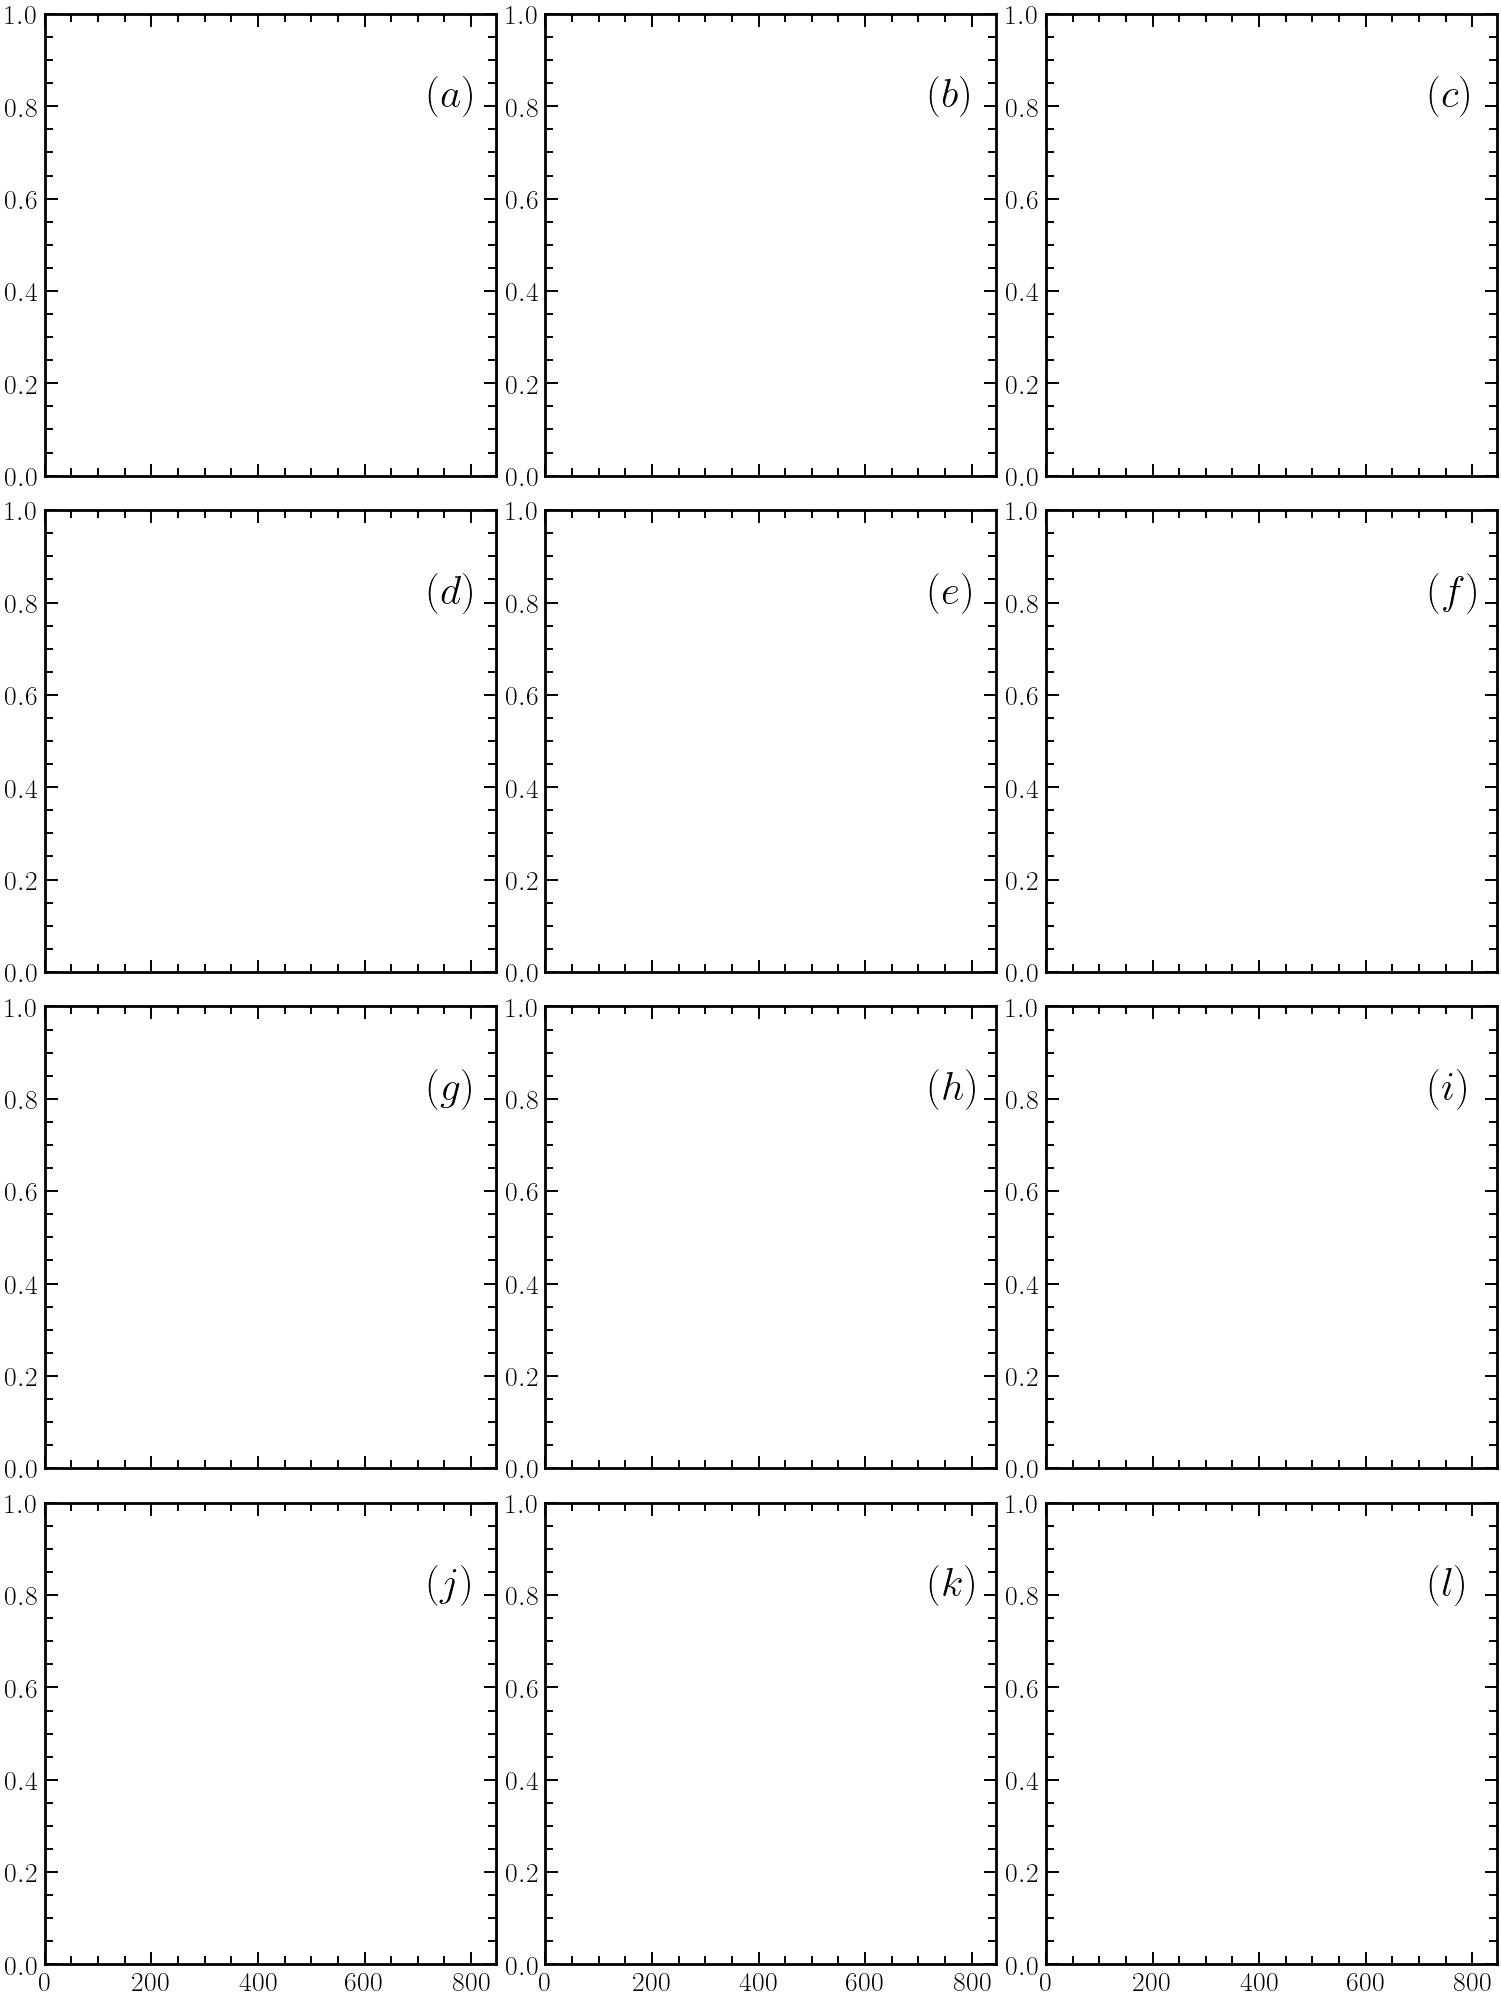

In [ ]:
ft = 0.1
c = 0.15
L_lst = [256, 512, 1024]
dim = 3
nc_lst = [1, 2, 4, 8]
p0 = 0.6
P0_lst = [0.1, 0.25, 0.50, 1.0]
base = 5
#p0_values = [0.3, 0.7, 1.0]
fig, axes = plt.subplots(len(nc_lst), len(L_lst), figsize=(3*base, 4*base), constrained_layout=True, sharex=True)
pc = 0.24881182
colors = [
    (0.90, 0.10, 0.10),  # red
    (0.10, 0.10, 0.90),  # blue
    (0.00, 0.60, 0.30),  # green
    (0.95, 0.50, 0.00),  # orange
    (0.65, 0.20, 0.75),  # purple
    (0.00, 0.70, 0.70),  # teal
    (0.55, 0.55, 0.00),  # olive
    (0.45, 0.25, 0.10),  # brown
]
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$',
              r'$(d)$', r'$(e)$', r'$(f)$',
              r'$(g)$', r'$(h)$', r'$(i)$',
              r'$(j)$', r'$(k)$', r'$(l)$',]

fs_labels_fig = 30
fs_l_fig = 27

t_max = 0
parms_list = []
for idx_nc, nc in enumerate(nc_lst):
    for index, L in enumerate(L_lst):
        ax = axes[idx_nc, index]
    
        rho = 1/nc            
        path = f"../SOP_data/published/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/fT_constant/fT_{ft:.6e}/c_{c:.6e}/rho_{rho:.4e}"
        
        fn = path + "/properties_mean_bundle.json"
        try:
            bundle = load_properties_bundle(fn)
    
            for P0 in P0_lst:
                group = get_group_by_p0_P0(bundle, p0_target=p0, P0_target=P0)

                data = group["orders"][order_mean]["data"]
                pmean = group["pc_sop"]["mean"]

                t = np.asarray(data["time"])
                pt = np.asarray(data["pt_mean"])
                t_max = max(t_max, max(t))
                ax.plot(t, pt, ls='solid', color=colors[idx], label=f'$i = {ord + 1}$')
        
        except KeyError:
            print(f"File not found: {fn}")
            parms_list.append((nc, ft, p0, path))
            continue
        except FileNotFoundError:
            print(f"File not found: {fn}")
            parms_list.append((nc, ft, p0, path))
            continue
        except Exception as e:
            print(f"Error occurred while processing {fn}: {e}")
            continue

        print(f'Loading data for nc={nc}, ft={ft}')
        
        t_max = max(t_max, max(time))
        ax.set_ylim(0.2, 0.6)
        ax.axhline(pc, color='k', ls='solid')
        #ax.set_ylim(0.245, 0.265)
        ax.set_box_aspect(1)
        
        if(idx_nc == 0):
            ax.text(0.08, 0.9, f'$z = {index+1}L$', transform=ax.transAxes , fontsize=fs_l_fig)
            ax.set_ylim(0.2, 0.30)
            ax.set_ylim(0.2, 0.3)
        if idx_nc==1:
            ax.set_ylim(0.2, 0.3)
        if idx_nc==2:
            ax.set_ylim(0.2, 0.35)
        if idx_nc == 3:
            ax.set_ylim(0.2, 0.6)
        
        if index==2:
            ax.legend()

        if index==0:
            ax.text(0.75, 0.9, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
            ax.legend()
            ax.set_ylabel(r'$\langle p(t) \rangle_{\mathrm{samples}}$')
        if idx_nc == len(nc_lst)-1:
            ax.set_xlabel(r'$t$')
        if index != 0:
            ax.tick_params(axis='y', labelleft=False)

for idx, ax in enumerate(axes.flatten()):
    ax.set_xlim(0, t_max)
    ax.text(0.85, 0.80, labels_fig[idx], transform=ax.transAxes , fontsize=fs_labels_fig)

plt.show()